In [41]:
!ffmpeg -y -ss 00:00:00 -i "F1C5LR.mp4" -t 15 -c:v libx264 -c:a aac "video_persoone_deux.mp4"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [42]:
import cv2
import os
import numpy

def decoupage_video(video_path, nom, repertoire_cible):
  '''
    args :
      video_path : chemin de la video à decouper en frames
      nom : nom des images après decoupe
      repertoire_cible : repertoire ou enregistrer les images
  '''

  cap = cv2.VideoCapture(video_path)
  ret, frame = cap.read()
  if not ret:
      print("Erreur : Impossible de lire la vidéo.")
      return

  os.makedirs(repertoire_cible, exist_ok=True)

  count = 0
  while ret:
    cv2.imwrite(os.path.join(repertoire_cible, f"{nom}_{count}.jpg"), frame)
    ret, frame = cap.read()
    count += 1
  cap.release()
  cv2.destroyAllWindows()
  print(f"Frames enregistrées dans {repertoire_cible}")


video_path = "/content/video_persoone_deux.mp4"
nom = "video_persoone_deux_frame_"
repertoire_cible = "frames"

decoupage_video(video_path, nom, repertoire_cible)

Frames enregistrées dans frames


✅ Vidéo lue avec succès. Résolution de l'image : 640 pixels de large x 360 pixels de haut.
✏️ Dessin du rectangle vert aux coordonnées : x=320, y=140, largeur=25, hauteur=55


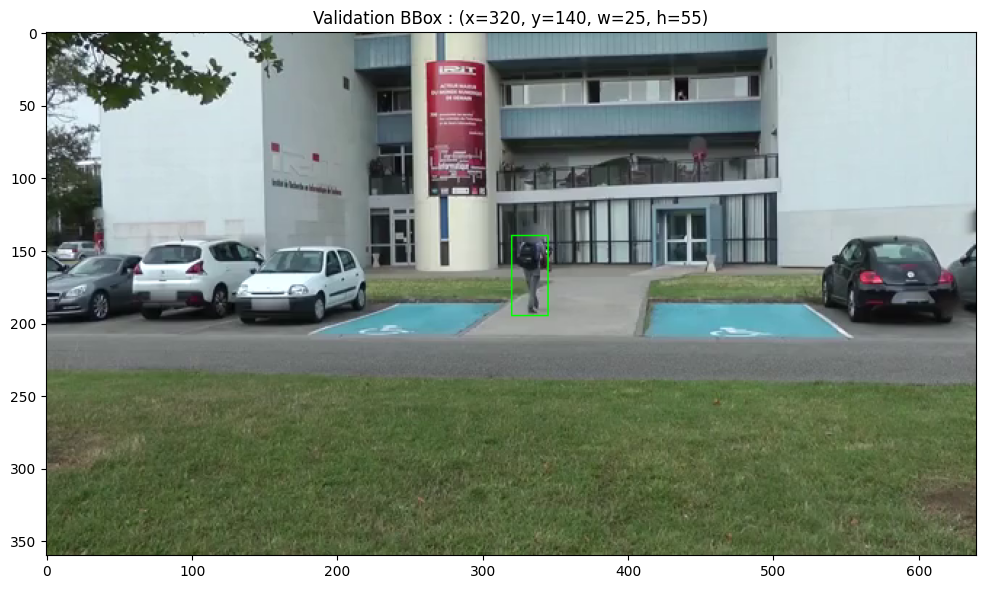

In [49]:
import cv2
import matplotlib.pyplot as plt

def show_first_frame(video_path, bbox=None):
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    frame_bbox = frame.copy()
    cap.release()

    if ret:
        print(f"✅ Vidéo lue avec succès. Résolution de l'image : {frame.shape[1]} pixels de large x {frame.shape[0]} pixels de haut.")

        if bbox is not None:
            # On force les coordonnées en entiers
            x, y, w, h = map(int, bbox)
            print(f"✏️ Dessin du rectangle vert aux coordonnées : x={x}, y={y}, largeur={w}, hauteur={h}")

            # On dessine avec une épaisseur très large (10 au lieu de 3)
            cv2.rectangle(frame_bbox, (x, y), (x + w, y + h), (0, 255, 0), 1)
        else:
            print("⚠️ Aucune Bounding Box n'a été fournie à la fonction.")

        # Colab/Matplotlib utilise RGB, OpenCV utilise BGR
        frame_rgb = cv2.cvtColor(frame_bbox, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(12, 8))
        plt.imshow(frame_rgb)

        if bbox is not None:
            plt.title(f"Validation BBox : (x={x}, y={y}, w={w}, h={h})")

        plt.axis('on')
        plt.show()
    else:
        print("❌ Erreur : Impossible de lire la vidéo.")

    return frame

# --- Utilisation ---
ma_bbox = ma_bbox = (320, 140, 25, 55)
frame = show_first_frame("video_persoone_deux.mp4", bbox=ma_bbox)

In [50]:
def enregistrer_frames_roi(frame, nom, repertoire_cible, bbox):

   os.makedirs(repertoire_cible, exist_ok=True)
   x, y, w, h = map(int, bbox)
   # Crop the frame to the bounding box region
   cropped_roi = frame[y:y+h, x:x+w]
   cv2.imwrite(os.path.join(repertoire_cible, f"{nom}_patch.jpg"), cropped_roi)
   print(f"Patch enregistre dans {repertoire_cible}")

ma_bbox = ma_bbox = (320, 140, 25, 55)
enregistrer_frames_roi(frame, "video_persoone_deux", "/content", ma_bbox)

Patch enregistre dans /content


In [51]:
import shutil
import os

def deplacer_fichiers_dans_rep(nom_repertoire, liste_fichiers_et_repertoire):
  """
    Déplace une liste de fichiers et/ou répertoires vers un répertoire cible,
    en conservant leur structure interne.

    Args:
      nom_repertoire (str): Le chemin du répertoire cible où déplacer les éléments.
      liste_fichiers_et_repertoire (list): Une liste de chemins de fichiers ou répertoires à déplacer.
  """
  os.makedirs(nom_repertoire, exist_ok=True)
  for element in liste_fichiers_et_repertoire:
    try:
      # shutil.move gère à la fois les fichiers et les répertoires
      shutil.move(element, os.path.join(nom_repertoire, os.path.basename(element)))
      print(f"Déplacé '{element}' vers '{nom_repertoire}'")
    except Exception as e:
      print(f"Erreur lors du déplacement de '{element}': {e}")

repertoire_final = "/video_persoone_deux"
liste_fichiers_et_repertoire = ["frames", "video_persoone_deux.mp4", "video_persoone_deux_patch.jpg"]
deplacer_fichiers_dans_rep(repertoire_final, liste_fichiers_et_repertoire)

Déplacé 'frames' vers '/video_persoone_deux'
Déplacé 'video_persoone_deux.mp4' vers '/video_persoone_deux'
Déplacé 'video_persoone_deux_patch.jpg' vers '/video_persoone_deux'


In [52]:
!zip -r video_persoone_deux.zip /video_persoone_deux

  adding: video_persoone_deux/ (stored 0%)
  adding: video_persoone_deux/video_persoone_deux_patch.jpg (deflated 11%)
  adding: video_persoone_deux/video_persoone_deux.mp4 (deflated 1%)
  adding: video_persoone_deux/frames/ (stored 0%)
  adding: video_persoone_deux/frames/video_persoone_deux_frame__156.jpg (deflated 0%)
  adding: video_persoone_deux/frames/video_persoone_deux_frame__287.jpg (deflated 0%)
  adding: video_persoone_deux/frames/video_persoone_deux_frame__199.jpg (deflated 0%)
  adding: video_persoone_deux/frames/video_persoone_deux_frame__281.jpg (deflated 0%)
  adding: video_persoone_deux/frames/video_persoone_deux_frame__345.jpg (deflated 0%)
  adding: video_persoone_deux/frames/video_persoone_deux_frame__343.jpg (deflated 0%)
  adding: video_persoone_deux/frames/video_persoone_deux_frame__234.jpg (deflated 0%)
  adding: video_persoone_deux/frames/video_persoone_deux_frame__130.jpg (deflated 0%)
  adding: video_persoone_deux/frames/video_persoone_deux_frame__211.jpg (def